# Construcción incremental sobre patrones únicos (método definitivo)

Este experimento contiene el método definitivo. Aprovecha que el embedding de cada relación depende solo de los tipos de las entidades y de la relación (tipo de cabeza, relación, tipo de cola), de modo que muchísimas tripletas distintas comparten un mismo patrón y, por tanto, un mismo vector. En lugar de agrupar todas las relaciones, se agrupan únicamente los patrones únicos y la etiqueta resultante se propaga después a todas sus repeticiones.

Esto resuelve a la vez dos problemas del agrupamiento sobre todas las relaciones: lo hace mucho más rápido (HDBSCAN trabaja sobre un número de puntos mucho menor) y elimina la fragilidad y la falta de reproducibilidad que introducían los vectores duplicados. Además, mientras un documento nuevo no aporte ningún patrón inédito, el conjunto de patrones únicos no cambia y se reutiliza el agrupamiento anterior sin volver a ejecutar HDBSCAN.

Se trabaja en el espacio original de 384 dimensiones, sin PCA. Como el agrupamiento se hace sobre patrones únicos, min_cluster_size pasa a contar patrones distintos en lugar de relaciones.

El criterio de parada conserva los cuatro indicadores ortogonales y la fase de rescate del ruido. La única diferencia en su cálculo afecta a la productividad: una relación aporta conocimiento nuevo cuando su patrón aparece por primera vez, con independencia de cómo la clasifique después el agrupamiento.

In [ ]:
# ============================================================
# EXPERIMENTO 11
# Construcción incremental sobre patrones únicos (método definitivo)
# ============================================================
# En esta celda se centralizan los parámetros principales del
# experimento para que el notebook sea más fácil de reproducir
# y modificar.

# Identificador del experimento.
# Se usará como prefijo en los ficheros de salida.
EXPERIMENTO = "Exp11"

#from google.colab import drive
#drive.mount('/content/drive')

# Carpeta donde se guardarán los resultados generados.
OUTPUT_DIR = "../Output/experiments"

#OUTPUT_DIR = (
#    "/content/drive/MyDrive/TFM/experiments"
#)

# Parámetros principales de HDBSCAN.
# min_cluster_size define el tamaño mínimo que debe tener un cluster.
MIN_CLUSTER_SIZE = 3

# min_samples controla la exigencia del algoritmo para considerar
# un punto como parte de una zona densa.
MIN_SAMPLES = 2

# Semilla para mantener reproducibilidad en aquellos procesos
# que puedan depender de aleatoriedad.
RANDOM_STATE = 42

In [5]:
# ============================================================
# IMPORTS
# ============================================================

import os
import re

import pandas as pd
import numpy as np


import hdbscan

import matplotlib.pyplot as plt


# ============================================================
# CREACIÓN DE CARPETAS DE SALIDA
# ============================================================

# Si la carpeta Outputs no existe, se crea automáticamente.
os.makedirs(OUTPUT_DIR, exist_ok=True)



print("Configuración cargada correctamente.")

Configuración cargada correctamente.


In [6]:
# ============================================================
# LEER DATAFRAME df_triplets DE FICHERO
# ============================================================

df_triplets = pd.read_pickle(
    "../Output/InformacionAutores10/df_triplets_InformacionAutores10_20260528.pkl"
)

embeddings = np.array(df_triplets["embedding"].tolist())

In [7]:
import numpy as np
from sklearn.neighbors import radius_neighbors_graph
from scipy.sparse.csgraph import connected_components
import hdbscan

MIN_CLUSTER_SIZE = 3
MIN_SAMPLES = 2
UMBRAL_SIMILITUD = 0.95

# --- Agrupamiento total sobre PATRONES ÚNICOS ---
df_unicos = df_triplets.drop_duplicates(subset="texto_embedding")
E_unicos = np.array(df_unicos["embedding"].tolist())

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean"
)
clusters_unicos = clusterer.fit_predict(E_unicos)

# Mapear la etiqueta del patrón a todas sus repeticiones
mapa_cluster = dict(zip(df_unicos["texto_embedding"].to_numpy(), clusters_unicos))
df_triplets["cluster"] = df_triplets["texto_embedding"].map(mapa_cluster).to_numpy()

clusters = df_triplets["cluster"].to_numpy()
total_relaciones = len(df_triplets)
total_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
total_noise = int((clusters == -1).sum())
noise_percentage = round(total_noise / total_relaciones * 100, 2)

# Recuento en PATRONES ÚNICOS (la otra convención posible)
patrones_unicos_ruido = int((clusters_unicos == -1).sum())
patrones_unicos_cluster = int((clusters_unicos >= 0).sum())

print("--- Agrupamiento total (patrones únicos), pre-rescate ---")
print(f"Relaciones analizadas: {total_relaciones}")
print(f"Patrones únicos: {len(df_unicos)}")
print(f"Grupos detectados: {total_clusters}")
print(f"Ruido en relaciones: {total_noise} ({noise_percentage}%)")
print(f"Ruido en patrones únicos: {patrones_unicos_ruido}")
print(f"Patrones únicos en grupo: {patrones_unicos_cluster}")

# --- Rescate del ruido sobre los embeddings ORIGINALES 384D ---
cluster_final = df_triplets["cluster"].to_numpy().copy()
ruido_mask = cluster_final == -1
idx_ruido = np.where(ruido_mask)[0]

nuevos_clusters_rescate = 0
relaciones_rescatadas = 0

if len(idx_ruido) >= 2:
    E_ruido = np.array(df_triplets.loc[ruido_mask, "embedding"].tolist())
    grafo = radius_neighbors_graph(
        E_ruido,
        radius=1.0 - UMBRAL_SIMILITUD,
        metric="cosine",
        include_self=False,
        mode="connectivity"
    )
    n_comp, etiquetas_comp = connected_components(grafo, directed=False)
    siguiente_id = int(cluster_final.max()) + 1 if cluster_final.max() >= 0 else 0
    for c in range(n_comp):
        miembros = idx_ruido[etiquetas_comp == c]
        if len(miembros) >= 2:
            cluster_final[miembros] = siguiente_id
            siguiente_id += 1
            nuevos_clusters_rescate += 1
            relaciones_rescatadas += len(miembros)

df_triplets["cluster_final"] = cluster_final

ruido_final = int((cluster_final == -1).sum())
clusters_final_total = len(set(cluster_final.tolist())) - (1 if -1 in cluster_final else 0)
total_relaciones_kg_final = clusters_final_total + ruido_final

# Recuento del KG final también en patrones únicos
ruido_final_patrones = int(
    df_triplets.loc[df_triplets["cluster_final"] == -1, "texto_embedding"].nunique()
)

print("--- Tras el rescate del ruido ---")
print(f"Nuevos grupos rescatados: {nuevos_clusters_rescate}")
print(f"Relaciones rescatadas: {relaciones_rescatadas}")
print(f"Ruido final (relaciones): {ruido_final}")
print(f"Ruido final (patrones únicos): {ruido_final_patrones}")
print(f"Grupos finales (original + rescate): {clusters_final_total}")
print(f"KG final (grupos + ruido, relaciones): {total_relaciones_kg_final}")
print(f"KG final (grupos + ruido, patrones únicos): {clusters_final_total + ruido_final_patrones}")

--- Agrupamiento total (patrones únicos), pre-rescate ---
Relaciones analizadas: 27838
Patrones únicos: 1497
Grupos detectados: 118
Ruido en relaciones: 4856 (17.44%)
Ruido en patrones únicos: 538
Patrones únicos en grupo: 959
--- Tras el rescate del ruido ---
Nuevos grupos rescatados: 249
Relaciones rescatadas: 4651
Ruido final (relaciones): 205
Ruido final (patrones únicos): 205
Grupos finales (original + rescate): 367
KG final (grupos + ruido, relaciones): 572
KG final (grupos + ruido, patrones únicos): 572


--- Agrupamiento total (patrones únicos), pre-rescate ---

Relaciones analizadas: 27838

Patrones únicos: 1497

Grupos detectados: 118

Ruido en relaciones: 4856 (17.44%)

Ruido en patrones únicos: 538

Patrones únicos en grupo: 959

--- Tras el rescate del ruido ---

Nuevos grupos rescatados: 249

Relaciones rescatadas: 4651

Ruido final (relaciones): 205

Ruido final (patrones únicos): 205

Grupos finales (original + rescate): 367

KG final (grupos + ruido, relaciones): 572

KG final (grupos + ruido, patrones únicos): 572

In [4]:
df_triplets.iloc[6]

id                                                                     40
Nombre                                                   Aburtes, José de
Anyo                                                                 1678
Frase                   Se ahogó en la Barra de Huelva estando en la c...
head                                                           Inés Gallo
head_type                                                             per
tail                                                      Barra de Huelva
tail_type                                                             loc
relation                                                   place of death
head_type_full                                                     person
tail_type_full                                                   location
texto_embedding                            person place of death location
embedding               [0.05328392, -0.0053135627, -0.029121956, -0.0...
translation_relation                  

In [5]:
df_triplets.groupby(["id", "Anyo"]).size()

df_counts = (
    df_triplets
    .groupby(["id", "Anyo"])
    .size()
    .reset_index(name="num_registros")
)

print(f"Número total de textos: {len(df_counts)}")
print(f"Número total de tripletas: {len(df_triplets)}")

Número total de textos: 2374
Número total de tripletas: 27838


In [8]:
# ============================================================
# CLUSTERING SEMÁNTICO CON HDBSCAN ITERATIVO (SIN PCA) - OPTIMIZADO
# (salta HDBSCAN cuando una iteración no aporta patrón único nuevo)
# CRITERIO ORTOGONAL (4 condiciones) + RESCATE DEL RUIDO
#
# Clave de esta versión: el clustering se hace SOLO sobre los
# PATRONES ÚNICOS (un representante por 'texto_embedding'). Como el
# embedding depende de tipo+relacion+tipo, muchas tripletas comparten
# embedding idéntico; clusterizar los únicos elimina los empates de
# los duplicados (que hacían el resultado frágil y no reproducible),
# es determinista y mucho más rápido. La etiqueta de cada patrón
# único se propaga después a todas sus repeticiones.
#
# Criterio de parada (4 condiciones ortogonales sobre la ventana):
#   1) productividad local baja   2) ARI alto
#   3) degradación baja (C->N)    4) consolidación baja (N->C)
# ============================================================
# ------------------------------------------------------------

from datetime import datetime
import time
import numpy as np
import pandas as pd
import hdbscan
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import radius_neighbors_graph
from scipy.sparse.csgraph import connected_components

try:
    from IPython.display import clear_output
except Exception:
    def clear_output(wait=False):
        pass


# ============================================================
# PARÁMETROS DE HDBSCAN
# ============================================================
# Al clusterizar PATRONES ÚNICOS, min_cluster_size cuenta
# patrones distintos, no relaciones. 


# ============================================================
# LOG
# ============================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_FILE = f"{OUTPUT_DIR}/log_mrebel_sinpca_dedup_{timestamp}.txt"


def escribir_log(texto, limpiar=False):
    if limpiar:
        clear_output(wait=True)
    print(texto)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(texto + "\n")


def formatear_tiempo(segundos):
    horas = int(segundos // 3600)
    minutos = int((segundos % 3600) // 60)
    segundos = segundos % 60
    return f"{horas:02d}:{minutos:02d}:{segundos:05.2f}"


# ============================================================
# PARÁMETROS DEL EXPERIMENTO
# ============================================================

# PARAR=True aplica el criterio de parada. PARAR=False recorre TODO
# el dataset (pasada completa para calibración).
# PARAR = True
PARAR = False

VENTANA_PARADA = 30
MIN_EMBEDDINGS_VENTANA = 300

# Productividad máxima de conocimiento nuevo en la ventana (0.04 = 4%).
PRODUCTIVIDAD_CONOCIMIENTO_TOL = 0.04

# Condiciones estructurales (SÍ deciden la parada).
ARI_MIN_TOL = 0.99           # ARI medio mínimo (estructura congelada)
DEGRADACION_MAX_TOL = 0.005  # degradación media máxima (cluster -> ruido)
CONSOLIDACION_MAX_TOL = 0.01 # consolidación media máxima (ruido -> cluster)

# Rescate del ruido (fase final): agrupa relaciones de ruido entre sí
# por similitud coseno alta sobre los embeddings ORIGINALES 384D.
UMBRAL_SIMILITUD = 0.95

RANDOM_STATE = 42


# ============================================================
# VARIABLES DE CONTROL
# ============================================================

inicio_total = time.time()

df_triplets_final = pd.DataFrame()
resultados_iteraciones = []
iteration = 0

# Etiquetas completas de la iteración anterior (para ARI y transiciones).
clusters_previos = None

# --- Caché del clustering de patrones únicos (optimización) ---
# El clustering solo cambia cuando aparece un patrón nuevo; mientras no
# aparezca, se reutiliza el mapeo y se salta HDBSCAN (resultado idéntico).
mapa_cluster = {}
n_unicos_clustering = -1
n_reclusterings = 0

# Conjunto de patrones (texto_embedding) ya vistos: define el conocimiento nuevo.
patrones_vistos = set()


# ============================================================
# ORDEN ALEATORIO REPRODUCIBLE DE LAS DUPLAS (id, Anyo)
# ============================================================

grupos_iteracion = list(df_triplets.groupby(["id", "Anyo"]))

rng = np.random.default_rng(RANDOM_STATE)
orden = rng.permutation(len(grupos_iteracion))
grupos_iteracion = [grupos_iteracion[i] for i in orden]


# ============================================================
# CLUSTERING ITERATIVO (espacio original 384D, sin PCA)
# ============================================================

escribir_log("=" * 50)
escribir_log("CLUSTERING ITERATIVO SIN PCA (sobre patrones únicos)")
escribir_log("=" * 50)

for (id_value, anyo_value), df_grupo in grupos_iteracion:

    inicio_iteracion = time.time()
    relaciones_antes_iteracion = len(df_triplets_final)
    iteration += 1

    # --------------------------------------------------------
    # Añadir las nuevas relaciones del grupo
    # --------------------------------------------------------
    df_triplets_final = pd.concat(
        [df_triplets_final, df_grupo],
        ignore_index=True
    )
    relaciones_anadidas_iteracion = (
        len(df_triplets_final) - relaciones_antes_iteracion
    )

    # --------------------------------------------------------
    # CONOCIMIENTO NUEVO: una relación aporta conocimiento nuevo solo si su
    # PATRÓN (texto_embedding) aparece por PRIMERA VEZ. Una copia de un
    # patrón ya visto -acabe luego en cluster o en ruido- es redundante.
    # Se calcula aquí (y se actualiza patrones_vistos) en TODA iteración,
    # para que la productividad caiga a 0 al agotarse los patrones distintos.
    # --------------------------------------------------------
    patrones_grupo = df_grupo["texto_embedding"].tolist()
    nuevos_patrones_distintos = len(set(patrones_grupo) - patrones_vistos)
    conocimiento_nuevo_iteracion = int(
        sum(1 for p in patrones_grupo if p not in patrones_vistos)
    )
    nuevas_redundantes = int(
        relaciones_anadidas_iteracion - conocimiento_nuevo_iteracion
    )
    ratio_conocimiento_nuevo_iteracion = (
        conocimiento_nuevo_iteracion / max(relaciones_anadidas_iteracion, 1)
    )
    patrones_vistos.update(patrones_grupo)

    # --------------------------------------------------------
    # PATRONES ÚNICOS (un representante por texto_embedding).
    # drop_duplicates conserva la primera aparición -> orden determinista.
    # --------------------------------------------------------
    df_unicos = df_triplets_final.drop_duplicates(subset="texto_embedding")
    textos_unicos = df_unicos["texto_embedding"].to_numpy()

    # --------------------------------------------------------
    # Si todavía no hay suficientes patrones únicos para HDBSCAN
    # --------------------------------------------------------
    if len(df_unicos) < MIN_CLUSTER_SIZE:

        df_triplets_final["cluster"] = -1

        fin_iteracion = time.time()
        tiempo_iteracion = formatear_tiempo(fin_iteracion - inicio_iteracion)
        tiempo_total_acumulado = formatear_tiempo(fin_iteracion - inicio_total)

        escribir_log(f"Iteración: {iteration}", limpiar=True)
        escribir_log(f"Procesando id={id_value}, anyo={anyo_value}")
        escribir_log(f"Relaciones añadidas en la iteración: {relaciones_anadidas_iteracion}")
        escribir_log(f"Relaciones acumuladas: {len(df_triplets_final)}")
        escribir_log(f"Patrones únicos: {len(df_unicos)}")
        escribir_log(f"Tiempo iteración: {tiempo_iteracion}")
        escribir_log(f"Tiempo total acumulado: {tiempo_total_acumulado}")
        escribir_log("Todavía no hay suficientes patrones únicos para ejecutar HDBSCAN")
        escribir_log("-" * 50)
        continue

    # --------------------------------------------------------
    # CLUSTERING con CACHÉ: solo se ejecuta HDBSCAN si ha aparecido
    # algún patrón único nuevo respecto al último clustering. Si no,
    # se reutiliza el mapeo anterior (mismo conjunto de únicos =>
    # HDBSCAN determinista daría exactamente lo mismo).
    # --------------------------------------------------------
    if len(df_unicos) != n_unicos_clustering:

        E_unicos = np.array(df_unicos["embedding"].tolist())

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=MIN_CLUSTER_SIZE,
            min_samples=MIN_SAMPLES,
            metric="euclidean",
            core_dist_n_jobs=1
        )
        clusters_unicos = clusterer.fit_predict(E_unicos)

        mapa_cluster = dict(zip(textos_unicos, clusters_unicos))
        n_unicos_clustering = len(df_unicos)
        n_reclusterings += 1
        reclusterizado = True
    else:
        reclusterizado = False   # se reutiliza el mapeo (sin HDBSCAN)

    # Propagar la etiqueta de cada patrón único a TODAS sus repeticiones.
    # 'clusters' mantiene el orden de filas de df_triplets_final.
    clusters = (
        df_triplets_final["texto_embedding"].map(mapa_cluster).to_numpy()
    )
    df_triplets_final["cluster"] = clusters

    # --------------------------------------------------------
    # MÉTRICAS BÁSICAS
    # --------------------------------------------------------
    total_relaciones = len(df_triplets_final)
    total_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    total_noise = int((clusters == -1).sum())
    noise_percentage = round(total_noise / total_relaciones * 100, 2)
    total_relaciones_kg = total_clusters + total_noise

    # En ESPACIO DE PATRONES ÚNICOS (en lo que se basa el clustering):
    # cuántos patrones distintos quedan en ruido y cuántos en algún cluster.
    patrones_unicos_ruido = int((clusters_unicos == -1).sum())
    patrones_unicos_cluster = int((clusters_unicos >= 0).sum())

    # Ruido aportado por las relaciones AÑADIDAS en esta iteración
    nuevo_ruido = int((clusters[relaciones_antes_iteracion:] == -1).sum())

    # --------------------------------------------------------
    # MÉTRICAS DE ESTABILIDAD Y MOVIMIENTO (vs iteración anterior)
    #   C->C: ARI | N->C: consolidación | C->N: degradación
    # --------------------------------------------------------
    alineado = (
        clusters_previos is not None
        and len(clusters_previos) == relaciones_antes_iteracion
        and relaciones_antes_iteracion >= 1
    )

    if len(resultados_iteraciones) == 0 or not alineado:
        delta_clusters = np.nan
        ruido_a_cluster = np.nan
        cluster_a_ruido = np.nan
        ari_estructura = np.nan
        tasa_consolidacion = np.nan
        tasa_degradacion = np.nan
    else:
        resultado_anterior = resultados_iteraciones[-1]
        delta_clusters = total_clusters - resultado_anterior["total_clusters"]

        labels_prev = clusters_previos
        labels_now = clusters[:relaciones_antes_iteracion]

        es_ruido_prev = labels_prev == -1
        es_ruido_now = labels_now == -1

        mask_cc = (~es_ruido_prev) & (~es_ruido_now)
        if int(mask_cc.sum()) >= 2:
            ari_estructura = float(
                adjusted_rand_score(labels_prev[mask_cc], labels_now[mask_cc])
            )
        else:
            ari_estructura = np.nan

        n_a_c = int((es_ruido_prev & ~es_ruido_now).sum())   # ruido -> cluster
        c_a_n = int((~es_ruido_prev & es_ruido_now).sum())   # cluster -> ruido
        ruido_prev_total = int(es_ruido_prev.sum())
        agrupado_prev_total = int((~es_ruido_prev).sum())

        tasa_consolidacion = n_a_c / max(ruido_prev_total, 1)
        tasa_degradacion = c_a_n / max(agrupado_prev_total, 1)
        ruido_a_cluster = n_a_c
        cluster_a_ruido = c_a_n

    # Guardar etiquetas actuales como referencia para la próxima iteración
    # (el conocimiento nuevo ya se calculó arriba, al añadir el grupo).
    clusters_previos = clusters.copy()

    # --------------------------------------------------------
    # TIEMPOS
    # --------------------------------------------------------
    fin_iteracion = time.time()
    tiempo_iteracion_segundos = fin_iteracion - inicio_iteracion
    tiempo_total_segundos = fin_iteracion - inicio_total
    tiempo_iteracion = formatear_tiempo(tiempo_iteracion_segundos)
    tiempo_total_acumulado = formatear_tiempo(tiempo_total_segundos)

    # --------------------------------------------------------
    # GUARDAR RESULTADOS DE ITERACIÓN
    # --------------------------------------------------------
    resultados_iteraciones.append({
        "iteration": iteration,
        "id": id_value,
        "anyo": anyo_value,
        "total_relaciones": total_relaciones,
        "total_clusters": total_clusters,
        "total_noise": total_noise,
        "noise_percentage": noise_percentage,
        "total_relaciones_kg": total_relaciones_kg,
        "patrones_unicos": len(df_unicos),
        "patrones_unicos_ruido": patrones_unicos_ruido,
        "patrones_unicos_cluster": patrones_unicos_cluster,
        "reclusterizado": reclusterizado,
        "nuevos_embeddings": len(df_grupo),
        "relaciones_anadidas_iteracion": relaciones_anadidas_iteracion,
        "delta_clusters": delta_clusters,
        "nuevo_ruido": nuevo_ruido,
        "nuevas_redundantes": nuevas_redundantes,
        "nuevos_patrones_distintos": nuevos_patrones_distintos,
        "conocimiento_nuevo_iteracion": conocimiento_nuevo_iteracion,
        "ratio_conocimiento_nuevo_iteracion": ratio_conocimiento_nuevo_iteracion,
        "ruido_a_cluster": ruido_a_cluster,
        "cluster_a_ruido": cluster_a_ruido,
        "ari_estructura": ari_estructura,
        "tasa_consolidacion": tasa_consolidacion,
        "tasa_degradacion": tasa_degradacion,
        "tiempo_iteracion_segundos": tiempo_iteracion_segundos,
        "tiempo_iteracion": tiempo_iteracion,
        "tiempo_total_segundos": tiempo_total_segundos,
        "tiempo_total_acumulado": tiempo_total_acumulado,
    })

    # --------------------------------------------------------
    # LOG DE ITERACIÓN
    # --------------------------------------------------------
    escribir_log(f"Iteración: {iteration}", limpiar=True)
    escribir_log(f"Procesando id={id_value}, anyo={anyo_value}")
    escribir_log(f"Relaciones añadidas en la iteración: {relaciones_anadidas_iteracion}")
    escribir_log(f"Relaciones acumuladas: {total_relaciones}")
    escribir_log(f"Patrones únicos: {len(df_unicos)} (reclustering: {reclusterizado})")
    escribir_log(f"Clusters detectados: {total_clusters}")
    escribir_log(f"Delta clusters (sin truncar): {delta_clusters}")
    escribir_log(f"Relaciones clasificadas como ruido: {total_noise}")
    escribir_log(f"Porcentaje de ruido: {noise_percentage}%")
    escribir_log(f"Patrones únicos en ruido: {patrones_unicos_ruido}")
    escribir_log(f"Patrones únicos en cluster: {patrones_unicos_cluster}")
    escribir_log(f"Relaciones finales KG: {total_relaciones_kg}")
    escribir_log(f"Nuevos patrones distintos: {nuevos_patrones_distintos}")
    escribir_log(f"Nuevas redundantes (cluster ya existente): {nuevas_redundantes}")
    escribir_log(f"Nuevo ruido: {nuevo_ruido}")
    escribir_log(f"Conocimiento nuevo iteración (no redundante): {conocimiento_nuevo_iteracion}")
    escribir_log(f"Ratio conocimiento nuevo iteración: {ratio_conocimiento_nuevo_iteracion}")
    escribir_log(f"Ruido a cluster (N->C): {ruido_a_cluster}")
    escribir_log(f"Cluster a ruido (C->N): {cluster_a_ruido}")
    escribir_log(f"ARI estructura (C->C): {ari_estructura}")
    escribir_log(f"Tasa consolidación (N->C): {tasa_consolidacion}")
    escribir_log(f"Tasa degradación (C->N): {tasa_degradacion}")
    escribir_log(f"Tiempo iteración: {tiempo_iteracion}")
    escribir_log(f"Tiempo total acumulado: {tiempo_total_acumulado}")
    escribir_log("-" * 50)

    # ========================================================
    # CRITERIO DE PARADA (4 condiciones ortogonales)
    # ========================================================
    if len(resultados_iteraciones) >= VENTANA_PARADA:

        ultimas_iteraciones = resultados_iteraciones[-VENTANA_PARADA:]

        embeddings_ventana = sum(
            item["nuevos_embeddings"] for item in ultimas_iteraciones
        )
        conocimiento_nuevo_ventana = sum(
            item["conocimiento_nuevo_iteracion"] for item in ultimas_iteraciones
        )
        ratio_productividad_conocimiento_ventana = (
            conocimiento_nuevo_ventana / max(embeddings_ventana, 1)
        )
        conocimiento_nuevo_bajo = (
            ratio_productividad_conocimiento_ventana <= PRODUCTIVIDAD_CONOCIMIENTO_TOL
        )

        valores_ari = [
            item["ari_estructura"] for item in ultimas_iteraciones
            if not pd.isna(item["ari_estructura"])
        ]
        media_ari_estructura = np.mean(valores_ari) if valores_ari else np.nan

        valores_consolidacion = [
            item["tasa_consolidacion"] for item in ultimas_iteraciones
            if not pd.isna(item["tasa_consolidacion"])
        ]
        media_tasa_consolidacion = (
            np.mean(valores_consolidacion) if valores_consolidacion else np.nan
        )

        valores_degradacion = [
            item["tasa_degradacion"] for item in ultimas_iteraciones
            if not pd.isna(item["tasa_degradacion"])
        ]
        media_tasa_degradacion = (
            np.mean(valores_degradacion) if valores_degradacion else np.nan
        )

        ari_estructura_estable = (
            (not pd.isna(media_ari_estructura))
            and (media_ari_estructura >= ARI_MIN_TOL)
        )
        degradacion_baja = (
            (not pd.isna(media_tasa_degradacion))
            and (media_tasa_degradacion <= DEGRADACION_MAX_TOL)
        )
        consolidacion_baja = (
            (not pd.isna(media_tasa_consolidacion))
            and (media_tasa_consolidacion <= CONSOLIDACION_MAX_TOL)
        )

        resultados_iteraciones[-1]["embeddings_ventana"] = embeddings_ventana
        resultados_iteraciones[-1]["conocimiento_nuevo_ventana"] = conocimiento_nuevo_ventana
        resultados_iteraciones[-1]["ratio_productividad_conocimiento_ventana"] = ratio_productividad_conocimiento_ventana
        resultados_iteraciones[-1]["conocimiento_nuevo_bajo"] = conocimiento_nuevo_bajo
        resultados_iteraciones[-1]["media_ari_estructura"] = media_ari_estructura
        resultados_iteraciones[-1]["media_tasa_consolidacion"] = media_tasa_consolidacion
        resultados_iteraciones[-1]["media_tasa_degradacion"] = media_tasa_degradacion
        resultados_iteraciones[-1]["ari_estructura_estable"] = ari_estructura_estable
        resultados_iteraciones[-1]["degradacion_baja"] = degradacion_baja
        resultados_iteraciones[-1]["consolidacion_baja"] = consolidacion_baja

        escribir_log(f"Embeddings ventana: {embeddings_ventana}")
        escribir_log(f"Conocimiento nuevo ventana: {conocimiento_nuevo_ventana}")
        escribir_log(f"Ratio productividad conocimiento ventana: {ratio_productividad_conocimiento_ventana}")
        escribir_log(f"Conocimiento nuevo bajo: {conocimiento_nuevo_bajo}")
        escribir_log(f"Media ARI estructura: {media_ari_estructura}")
        escribir_log(f"ARI estructura estable: {ari_estructura_estable}")
        escribir_log(f"Media tasa degradación: {media_tasa_degradacion}")
        escribir_log(f"Degradación baja: {degradacion_baja}")
        escribir_log(f"Media tasa consolidación: {media_tasa_consolidacion}")
        escribir_log(f"Consolidación baja: {consolidacion_baja}")
        escribir_log("-" * 50)

        if (
            PARAR
            and embeddings_ventana >= MIN_EMBEDDINGS_VENTANA
            and conocimiento_nuevo_bajo
            and ari_estructura_estable
            and degradacion_baja
            and consolidacion_baja
        ):
            escribir_log("Criterio de parada alcanzado.")
            escribir_log(
                "Motivo: baja productividad local, estructura estable (ARI alto), "
                "baja degradación (C->N) y baja consolidación (N->C)."
            )
            break


# ============================================================
# FASE DE RESCATE DEL RUIDO (post-parada)
# ============================================================

escribir_log("=" * 50)
escribir_log("FASE DE RESCATE DEL RUIDO")
escribir_log("=" * 50)

cluster_final = df_triplets_final["cluster"].to_numpy().copy()
ruido_mask = cluster_final == -1
idx_ruido = np.where(ruido_mask)[0]

nuevos_clusters_rescate = 0
relaciones_rescatadas = 0

if len(idx_ruido) >= 2:

    E_ruido = np.array(
        df_triplets_final.loc[ruido_mask, "embedding"].tolist()
    )

    grafo = radius_neighbors_graph(
        E_ruido,
        radius=1.0 - UMBRAL_SIMILITUD,
        metric="cosine",
        include_self=False,
        mode="connectivity"
    )

    n_comp_rescate, etiquetas_comp = connected_components(grafo, directed=False)

    siguiente_id = int(cluster_final.max()) + 1 if cluster_final.max() >= 0 else 0

    for c in range(n_comp_rescate):
        miembros = idx_ruido[etiquetas_comp == c]
        if len(miembros) >= 2:
            cluster_final[miembros] = siguiente_id
            siguiente_id += 1
            nuevos_clusters_rescate += 1
            relaciones_rescatadas += len(miembros)

df_triplets_final["cluster_final"] = cluster_final

ruido_final = int((cluster_final == -1).sum())
clusters_final_total = len(set(cluster_final.tolist())) - (1 if -1 in cluster_final else 0)
total_relaciones_kg_final = clusters_final_total + ruido_final

escribir_log(f"Umbral de similitud: {UMBRAL_SIMILITUD}")
escribir_log(f"Relaciones de ruido antes del rescate: {len(idx_ruido)}")
escribir_log(f"Nuevos clusters rescatados: {nuevos_clusters_rescate}")
escribir_log(f"Relaciones rescatadas: {relaciones_rescatadas}")
escribir_log(f"Ruido final: {ruido_final}")
escribir_log(f"Clusters finales (original + rescate): {clusters_final_total}")
escribir_log(f"Relaciones finales KG (cluster_final): {total_relaciones_kg_final}")
escribir_log("-" * 50)


# ============================================================
# GUARDADO DE RESULTADOS
# ============================================================

df_resultados_iteraciones = pd.DataFrame(resultados_iteraciones)

df_triplets_final.to_pickle(
    f"{OUTPUT_DIR}/df_triplets_final_sinpca_dedup_{timestamp}.pkl"
)
df_resultados_iteraciones.to_pickle(
    f"{OUTPUT_DIR}/df_resultados_iteraciones_sinpca_dedup_{timestamp}.pkl"
)


# ============================================================
# RESUMEN FINAL
# ============================================================

escribir_log("Proceso finalizado.")
escribir_log(f"Log guardado en: {LOG_FILE}")
escribir_log(f"Iteraciones ejecutadas: {iteration}")
escribir_log(f"Reclusterings reales (llamadas a HDBSCAN): {n_reclusterings}")
escribir_log(f"Relaciones finales acumuladas: {len(df_triplets_final)}")
escribir_log(f"Clusters detectados (antes del rescate): {total_clusters}")
escribir_log(f"Relaciones clasificadas como ruido (antes del rescate): {total_noise}")
escribir_log(f"Porcentaje de ruido: {noise_percentage}%")
escribir_log("--- Tras el rescate del ruido ---")
escribir_log(f"Clusters finales: {clusters_final_total}")
escribir_log(f"Ruido final: {ruido_final}")
escribir_log(f"Relaciones finales KG (cluster_final): {total_relaciones_kg_final}")

fin_total = time.time()
tiempo_total = fin_total - inicio_total
minutos_total = int(tiempo_total // 60)
segundos_total = tiempo_total % 60
print(f"Tiempo de ejecución total: {minutos_total} min {segundos_total:.2f} s")


Iteración: 2374
Procesando id=2877, anyo=1606
Relaciones añadidas en la iteración: 6
Relaciones acumuladas: 27838
Patrones únicos: 1497 (reclustering: True)
Clusters detectados: 117
Delta clusters (sin truncar): -3
Relaciones clasificadas como ruido: 4869
Porcentaje de ruido: 17.49%
Patrones únicos en ruido: 532
Patrones únicos en cluster: 965
Relaciones finales KG: 4986
Nuevos patrones distintos: 1
Nuevas redundantes (cluster ya existente): 5
Nuevo ruido: 0
Conocimiento nuevo iteración (no redundante): 1
Ratio conocimiento nuevo iteración: 0.16666666666666666
Ruido a cluster (N->C): 47
Cluster a ruido (C->N): 154
ARI estructura (C->C): 0.9997353728392888
Tasa consolidación (N->C): 0.009869802603947922
Tasa degradación (C->N): 0.006675335934113567
Tiempo iteración: 00:00:01.32
Tiempo total acumulado: 00:06:26.73
--------------------------------------------------
Embeddings ventana: 316
Conocimiento nuevo ventana: 8
Ratio productividad conocimiento ventana: 0.02531645569620253
Conocimie

In [ ]:
# ============================================================
# LEER DATAFTAME ITERACIÓN COMPLETA DE FICHERO
# ============================================================

df_resultados_iteraciones = pd.read_pickle(
    "../Output/experiments/df_resultados_iteraciones_sinpca_dedup_20260630_051928.pkl"
)

df_triplets_final = pd.read_pickle(
    "../Output/experiments/df_triplets_final_sinpca_dedup_20260630_051928.pkl"
)



Guardado en: evolucion_conocimiento.png
27,838 relaciones (1497 patrones únicos) → KG = 565 (363 clusters + 202 ruido)


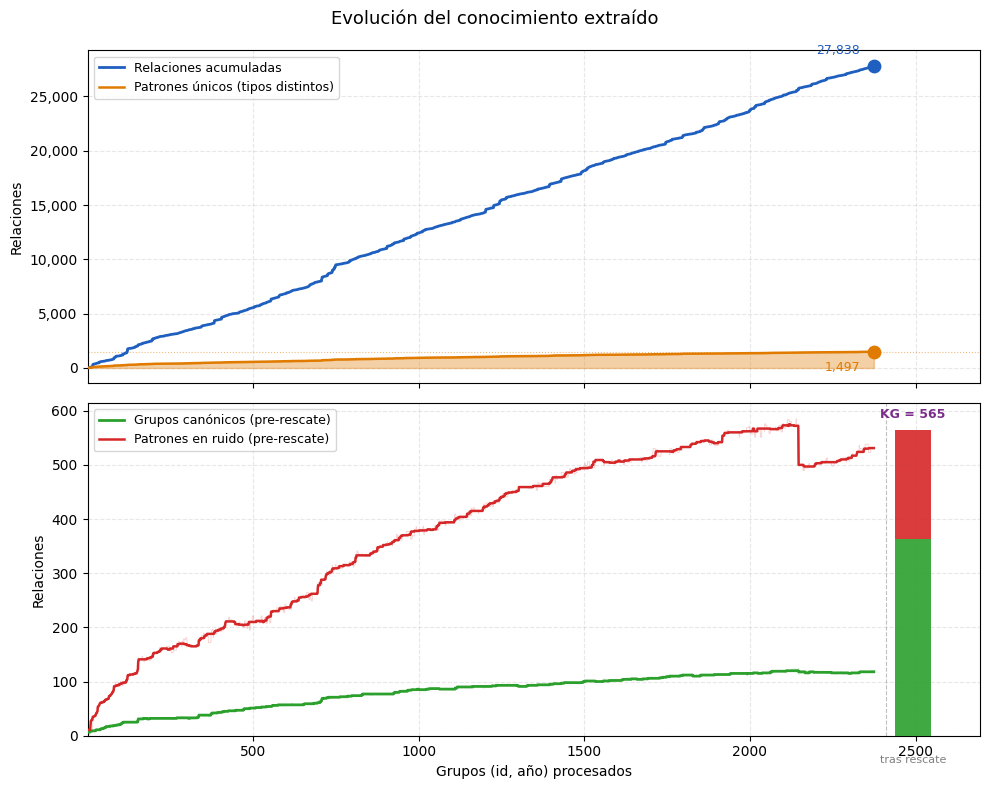

In [9]:
"""
Evolución del conocimiento extraído (deduplicación, espacio de patrones únicos).

Panel superior: relaciones totales acumuladas + patrones únicos (eje único).
Panel inferior: trayectoria pre-rescate (grupos canónicos + patrones en ruido)
               y, a la derecha, barra apilada con el estado FINAL tras el rescate
               (clusters + ruido = KG).

Nota: la curva de ruido pre-rescate oscila al final porque HDBSCAN reparticiona
el conjunto cada vez que aparece un patrón nuevo tardío. Por eso se dibuja el dato
crudo de fondo (tenue) y una línea suavizada (mediana móvil) encima para leer la
tendencia. El estado relevante es el de la barra final, tras el rescate.

Requiere en df: iteration, total_relaciones, patrones_unicos, total_clusters,
                patrones_unicos_ruido.

Uso:
    cf = df_triplets_final["cluster_final"]
    graficar_evolucion_conocimiento(
        df_resultados_iteraciones,
        clusters_final = cf[cf >= 0].nunique(),
        ruido_final    = df_triplets_final.loc[cf == -1, "texto_embedding"].nunique(),
    )
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

OUTPUT_PATH = "evolucion_conocimiento.png"

COLOR_REL   = "#1f5fbf"
COLOR_PAT   = "#e07b00"
COLOR_CL    = "#2ca02c"
COLOR_RUIDO = "#d62728"
COLOR_KG    = "#7b2d8b"


def _suavizar(serie, ventana):
    if not ventana or ventana < 2:
        return serie
    return serie.rolling(ventana, center=True, min_periods=1).median()


def graficar_evolucion_conocimiento(
    df,
    clusters_final=None,
    ruido_final=None,
    suavizado=25,
    output_path=OUTPUT_PATH,
):
    df  = df.sort_values("iteration").reset_index(drop=True)
    x   = df["iteration"]
    x0, x_f = int(x.iloc[0]), int(x.iloc[-1])
    rango = max(x_f - x0, 1)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    fig.suptitle("Evolución del conocimiento extraído", fontsize=13)

    # ----------------------------------------------------------------
    # PANEL SUPERIOR
    # ----------------------------------------------------------------
    rel, pat = df["total_relaciones"], df["patrones_unicos"]
    ax1.plot(x, rel, lw=2, color=COLOR_REL, label="Relaciones acumuladas", zorder=3)
    ax1.fill_between(x, pat, alpha=0.35, color=COLOR_PAT, zorder=2)
    ax1.plot(x, pat, lw=1.8, color=COLOR_PAT,
             label="Patrones únicos (tipos distintos)", zorder=3)

    y_rel, y_pat = int(rel.iloc[-1]), int(pat.iloc[-1])
    ax1.scatter([x_f], [y_rel], s=80, zorder=5, color=COLOR_REL)
    ax1.scatter([x_f], [y_pat], s=80, zorder=5, color=COLOR_PAT)
    ax1.annotate(f"{y_rel:,}", xy=(x_f, y_rel), xytext=(-10, 8),
                 textcoords="offset points", fontsize=9, color=COLOR_REL, ha="right")
    ax1.annotate(f"{y_pat:,}", xy=(x_f, y_pat), xytext=(-10, -14),
                 textcoords="offset points", fontsize=9, color=COLOR_PAT, ha="right")
    ax1.axhline(y_pat, color=COLOR_PAT, lw=0.8, ls=":", alpha=0.5)

    ax1.set_ylabel("Relaciones")
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax1.legend(loc="upper left", fontsize=9)
    ax1.grid(True, linestyle="--", alpha=0.3)

    # ----------------------------------------------------------------
    # PANEL INFERIOR – trayectoria pre-rescate (suavizada) + barra final
    # ----------------------------------------------------------------
    cl = df["total_clusters"]
    if "patrones_unicos_ruido" in df.columns:
        ru = df["patrones_unicos_ruido"]
        lbl_ru = "Patrones en ruido (pre-rescate)"
    else:
        ru = df["total_noise"]
        lbl_ru = "Ruido en relaciones (pre-rescate)"

    cl_s, ru_s = _suavizar(cl, suavizado), _suavizar(ru, suavizado)

    # dato crudo de fondo (tenue) + tendencia suavizada encima
    if suavizado and suavizado >= 2:
        ax2.plot(x, ru, lw=0.7, color=COLOR_RUIDO, alpha=0.20, zorder=1)
        ax2.plot(x, cl, lw=0.7, color=COLOR_CL, alpha=0.20, zorder=1)
    ax2.plot(x, cl_s, lw=2,   color=COLOR_CL,    label="Grupos canónicos (pre-rescate)", zorder=3)
    ax2.plot(x, ru_s, lw=1.8, color=COLOR_RUIDO, label=lbl_ru, zorder=3)

    if clusters_final is not None and ruido_final is not None:
        kg_final = clusters_final + ruido_final
        x_bar = x_f + rango * 0.05
        w = rango * 0.045
        ax2.axvline(x_f + rango * 0.015, color="gray", lw=0.8, ls="--", alpha=0.5)
        ax2.bar(x_bar, clusters_final, width=w, color=COLOR_CL, alpha=0.9, zorder=4)
        ax2.bar(x_bar, ruido_final, width=w, bottom=clusters_final,
                color=COLOR_RUIDO, alpha=0.9, zorder=4)
        ax2.annotate(f"{clusters_final}\nclusters", (x_bar, clusters_final / 2),
                     ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        ax2.annotate(f"{ruido_final}\nruido", (x_bar, clusters_final + ruido_final / 2),
                     ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        ax2.annotate(f"KG = {kg_final}", (x_bar, kg_final),
                     xytext=(0, 6), textcoords="offset points",
                     ha="center", va="bottom", fontsize=9, color=COLOR_KG, fontweight="bold")
        ax2.text(x_bar, -max(cl.max(), ru.max()) * 0.06, "tras rescate",
                 ha="center", va="top", fontsize=8, color="gray")
        ax2.set_xlim(x0, x_bar + w + rango * 0.04)
    else:
        print("[aviso] No se dibujó la barra del KG: faltan 'clusters_final' y "
              "'ruido_final'.\n        Pásalos desde df_triplets_final, p.ej.:\n"
              "        cf = df_triplets_final['cluster_final']\n"
              "        clusters_final = cf[cf>=0].nunique()\n"
              "        ruido_final = df_triplets_final.loc[cf==-1,'texto_embedding'].nunique()")

    ax2.set_ylabel("Relaciones")
    ax2.set_xlabel("Grupos (id, año) procesados")
    ax2.set_ylim(bottom=0)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax2.legend(loc="upper left", fontsize=9)
    ax2.grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        msg = f"Guardado en: {output_path}\n{int(rel.iloc[-1]):,} relaciones ({int(pat.iloc[-1])} patrones únicos)"
        if clusters_final is not None and ruido_final is not None:
            msg += f" → KG = {clusters_final + ruido_final} ({clusters_final} clusters + {ruido_final} ruido)"
        print(msg)
    plt.close(fig)
    return fig


cf = df_triplets_final["cluster_final"]
clusters_final = cf[cf >= 0].nunique()                                   # 359
ruido_final    = df_triplets_final.loc[cf == -1, "texto_embedding"].nunique()  # 217

graficar_evolucion_conocimiento(
    df_resultados_iteraciones,
    clusters_final = clusters_final,
    ruido_final    = ruido_final,
    suavizado      = 45,
)



In [25]:
"""
Ilustración de la duplicación de patrones (texto_embedding).

Muestra que muchas relaciones (tripletas) distintas, en distintos documentos
(id, Anyo) y con entidades distintas, comparten el MISMO texto_embedding y, por
tanto, el mismo vector de embedding. Esa es la razón por la que el algoritmo
clusteriza solo los patrones únicos y se salta el reclustering cuando un
documento nuevo no aporta ningún patrón nuevo.

Funciona con df_triplets_final o df_triplets (ambos tienen las mismas columnas
relevantes: id, Anyo, head, relation, tail, texto_embedding, embedding).
"""

import numpy as np
import pandas as pd


def ejemplos_duplicacion(
    df,
    relaciones=("spouse", "place of birth"),
    n_ejemplos=6,
    top_patrones=10,
    seed=42,
):
    rng = np.random.default_rng(seed)

    total = len(df)
    n_unicos = df["texto_embedding"].nunique()

    print("=" * 70)
    print("DUPLICACIÓN DE PATRONES (texto_embedding = tipo + relación + tipo)")
    print("=" * 70)
    print(f"Relaciones totales      : {total:,}")
    print(f"Patrones únicos         : {n_unicos:,}")
    print(f"Factor de duplicación   : {total / n_unicos:.1f}x  "
          f"(cada patrón aparece de media {total / n_unicos:.0f} veces)")

    # ------------------------------------------------------------------
    # Patrones más repetidos
    # ------------------------------------------------------------------
    vc = df["texto_embedding"].value_counts()
    docs_por_patron = (
        df.groupby("texto_embedding")[["id", "Anyo"]]
        .apply(lambda g: g.drop_duplicates().shape[0])
    )
    print("\nPatrones más repetidos:")
    print(f"  {'texto_embedding':<60} {'veces':>7} {'docs':>6}")
    for patron, veces in vc.head(top_patrones).items():
        print(f"  {patron[:60]:<60} {veces:>7,} {int(docs_por_patron[patron]):>6}")

    # ------------------------------------------------------------------
    # Ejemplos detallados para relaciones claras
    # ------------------------------------------------------------------
    for rel in relaciones:
        sub_rel = df[df["relation"] == rel]
        if sub_rel.empty:
            print(f"\n[aviso] no hay relaciones '{rel}' en el dataframe")
            continue

        # patrón dominante de esa relación
        patron = sub_rel["texto_embedding"].value_counts().idxmax()
        subp = df[df["texto_embedding"] == patron]

        # traducción si existe
        trad = ""
        if "translation_relation" in df.columns:
            tr = sub_rel["translation_relation"].dropna()
            if not tr.empty:
                trad = f"  ({tr.value_counts().idxmax()})"

        # comprobar que los embeddings son idénticos
        embs = np.array(subp["embedding"].tolist())
        cos_min = float((embs @ embs[0]).min())
        dif_max = float(np.linalg.norm(embs - embs[0], axis=1).max())
        n_docs = subp[["id", "Anyo"]].drop_duplicates().shape[0]

        print("\n" + "-" * 70)
        print(f"Relación '{rel}'{trad}")
        print(f"  texto_embedding : \"{patron}\"")
        print(f"  aparece {len(subp):,} veces en {n_docs:,} documentos (id, año) distintos")
        print(f"  embeddings idénticos: coseno mínimo {cos_min:.6f}, "
              f"diferencia máxima {dif_max:.1e}")

        # n ejemplos de documentos distintos y entidades distintas
        muestra = subp.drop_duplicates(subset=["id", "Anyo", "head", "tail"])
        k = min(n_ejemplos, len(muestra))
        idx = rng.choice(len(muestra), size=k, replace=False)
        muestra = muestra.iloc[np.sort(idx)]

        print(f"\n  {'id':>6} {'año':>6}   {'head':<26} {'relation':<16} {'tail'}")
        for _, r in muestra.iterrows():
            print(f"  {str(r['id']):>6} {str(r['Anyo']):>6}   "
                  f"{str(r['head'])[:26]:<26} {str(r['relation'])[:16]:<16} {r['tail']}")

        print(f"\n  → Entidades distintas, pero MISMO texto_embedding y MISMO vector.")
        print(f"    El algoritmo lo clusteriza UNA vez; las {len(subp):,} apariciones "
              f"reutilizan esa etiqueta.")

    # ------------------------------------------------------------------
    # Motivación de saltar el reclustering: un documento tardío típico
    # no aporta ningún patrón nuevo
    # ------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("POR QUÉ SE PUEDE SALTAR EL RECLUSTERING")
    print("=" * 70)
    vistos = set()
    nuevos_por_doc = []
    for (idv, ayv), g in df.groupby(["id", "Anyo"], sort=False):
        pats = g["texto_embedding"].tolist()
        nuevos = sum(1 for p in set(pats) if p not in vistos)
        nuevos_por_doc.append(nuevos)
        vistos.update(pats)
    nuevos_por_doc = np.array(nuevos_por_doc)
    sin_nuevos = int((nuevos_por_doc == 0).sum())
    print(f"Documentos (id, año) totales        : {len(nuevos_por_doc):,}")
    print(f"Documentos que NO aportan patrón nuevo: {sin_nuevos:,} "
          f"({sin_nuevos / len(nuevos_por_doc) * 100:.0f}%)")
    print("En esos documentos el conjunto de patrones únicos no cambia, así que")
    print("HDBSCAN daría exactamente el mismo resultado y se reutiliza el anterior.")



ejemplos_duplicacion(df_triplets)


DUPLICACIÓN DE PATRONES (texto_embedding = tipo + relación + tipo)
Relaciones totales      : 27,838
Patrones únicos         : 1,497
Factor de duplicación   : 18.6x  (cada patrón aparece de media 19 veces)

Patrones más repetidos:
  texto_embedding                                                veces   docs
  person spouse person                                           2,370    732
  concept part of concept                                        2,075    582
  location located in the administrative territorial entity lo   1,570    623
  person place of birth location                                 1,159    779
  concept author person                                            946    452
  person occupation concept                                        930    549
  concept located in the administrative territorial entity loc     920    451
  concept instance of concept                                      776    383
  concept subclass of concept                                      7

Figura guardada en: trayectoria_metricas.png  (4 paneles, mostrar='ambas')


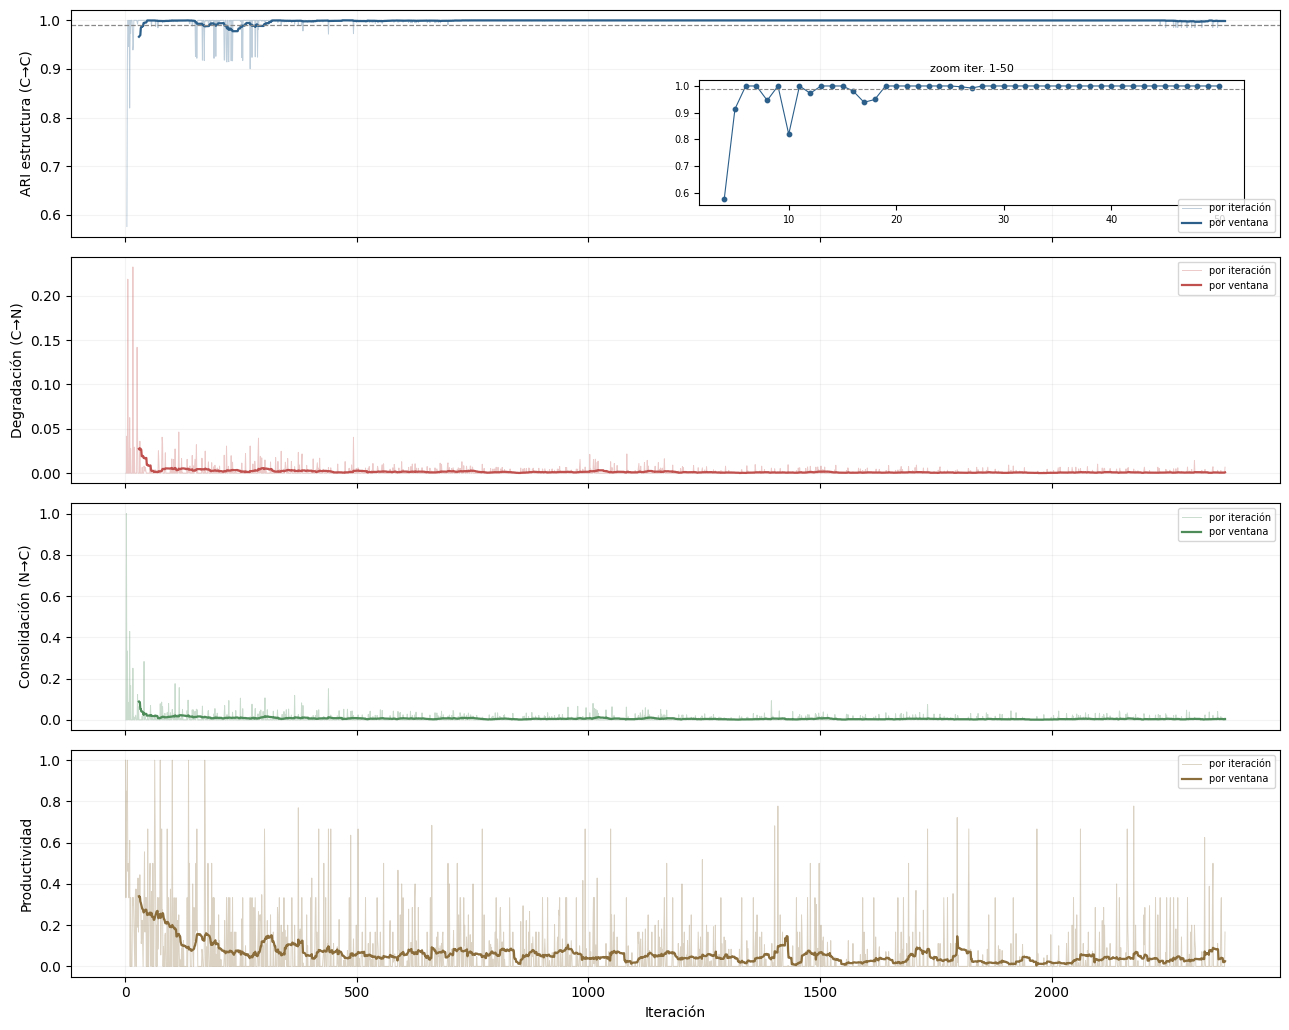

In [10]:
"""
Trayectoria de las métricas del criterio de parada, a partir del dataframe de
resultados por iteración.

Cada métrica existe en dos formas en el dataframe:
  - por ITERACIÓN: la señal cruda de cada paso.
  - por VENTANA  : la media móvil, que es la que usa la decisión de parada.

Por defecto se muestran ambas: la de iteración tenue y la de ventana gruesa.
Con `mostrar="ventana"` o `mostrar="iteracion"` se enseña solo una.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Configuración
# ---------------------------------------------------------------------------
ARI_UMBRAL = 0.99          # umbral de referencia que se dibuja en el panel ARI
ZOOM_MAX = 50              # rango de iteraciones del recuadro de zoom (panel ARI)
DELTA_YLIM = (-3, 6)       # recorte vertical del panel de delta de clusters
OUTPUT_PATH = "trayectoria_metricas.png"   # imagen de salida (None = no guardar)

COL_ITER = "iteration"

# Especificación de las métricas a dibujar: (etiqueta, col_iteracion, col_ventana,
# tipo, color). col_ventana=None -> la métrica no tiene forma de ventana.
METRICAS = [
    ("ARI estructura (C→C)",  "ari_estructura",                     "media_ari_estructura",                     "linea",  "#2c5f8a"),
    ("Degradación (C→N)",     "tasa_degradacion",                   "media_tasa_degradacion",                   "linea",  "#c0504d"),
    ("Consolidación (N→C)",   "tasa_consolidacion",                 "media_tasa_consolidacion",                 "linea",  "#4e8c5a"),
    ("Productividad",         "ratio_conocimiento_nuevo_iteracion", "ratio_productividad_conocimiento_ventana", "linea",  "#8a6d3b"),
]


def _panel_linea(ax, df, col_iter, col_vent, color, mostrar):
    if mostrar in ("ambas", "iteracion") and col_iter in df:
        ax.plot(df[COL_ITER], df[col_iter], lw=0.7, color=color,
                alpha=0.30 if mostrar == "ambas" else 0.9,
                label="por iteración")
    if mostrar in ("ambas", "ventana") and col_vent and col_vent in df:
        ax.plot(df[COL_ITER], df[col_vent], lw=1.6, color=color,
                label="por ventana")
    if mostrar == "ambas" and col_vent:
        ax.legend(fontsize=7, loc="best")


def _panel_barras(ax, df, col_iter, color):
    d = df.dropna(subset=[col_iter])
    colores = np.where(d[col_iter] >= 0, color, "#b94a48")
    ax.bar(d[COL_ITER], d[col_iter], width=1.0, color=colores)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylim(*DELTA_YLIM)


def _zoom_ari(ax, df, color):
    axz = ax.inset_axes([0.52, 0.14, 0.45, 0.55])
    dz = df[df[COL_ITER] <= ZOOM_MAX]
    axz.plot(dz[COL_ITER], dz["ari_estructura"], lw=0.8, color=color)
    axz.scatter(dz[COL_ITER], dz["ari_estructura"], s=10, color=color)
    axz.axhline(ARI_UMBRAL, ls="--", lw=0.8, color="#888")
    axz.set_title(f"zoom iter. 1-{ZOOM_MAX}", fontsize=8)
    axz.tick_params(labelsize=7)


def graficar_trayectoria_metricas(df, mostrar="ambas", output_path=OUTPUT_PATH,
                                  metricas=METRICAS):

    df = df.sort_values(COL_ITER).reset_index(drop=True)

    metricas = [m for m in metricas if m[1] in df.columns]
    n = len(metricas)
    fig, axes = plt.subplots(n, 1, figsize=(13, 2.6 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, (etq, col_it, col_vt, tipo, color) in zip(axes, metricas):
        if tipo == "barras":
            _panel_barras(ax, df, col_it, color)
        else:
            _panel_linea(ax, df, col_it, col_vt, color, mostrar)
            if col_it == "ari_estructura":
                ax.axhline(ARI_UMBRAL, ls="--", lw=0.9, color="#888")
                _zoom_ari(ax, df, color)
        ax.set_ylabel(etq)
        ax.grid(alpha=0.15)

    axes[-1].set_xlabel("Iteración")
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=130, bbox_inches="tight")
        print(f"Figura guardada en: {output_path}  ({n} paneles, mostrar='{mostrar}')")
    return fig


fig = graficar_trayectoria_metricas(df_resultados_iteraciones)
plt.show()

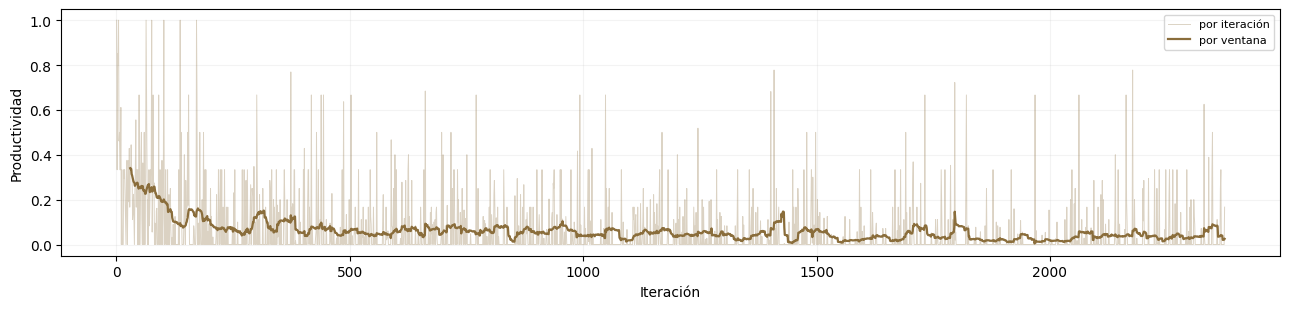

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Columnas de productividad en el dataframe de iteraciones
COL_ITER = "iteration"
COL_PROD_ITER = "ratio_conocimiento_nuevo_iteracion"        # señal por iteración (cruda)
COL_PROD_VENT = "ratio_productividad_conocimiento_ventana"  # agregada en la ventana
COLOR = "#8a6d3b"

OUTPUT_PATH = "exp8_productividad.png"

def graficar_productividad(df, mostrar="ambas", output_path=OUTPUT_PATH):
    df = df.sort_values(COL_ITER).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(13, 3.2))

    if mostrar in ("ambas", "iteracion") and COL_PROD_ITER in df:
        ax.plot(df[COL_ITER], df[COL_PROD_ITER], lw=0.7, color=COLOR,
                alpha=0.30 if mostrar == "ambas" else 0.9,
                label="por iteración")

    if mostrar in ("ambas", "ventana") and COL_PROD_VENT in df:
        ax.plot(df[COL_ITER], df[COL_PROD_VENT], lw=1.6, color=COLOR,
                label="por ventana")

    ax.set_xlabel("Iteración")
    ax.set_ylabel("Productividad")
    ax.grid(alpha=0.15)
    if mostrar == "ambas":
        ax.legend(fontsize=8, loc="best")

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        plt.savefig(output_path.replace(".png", ".svg"), bbox_inches="tight")
    return fig

fig = graficar_productividad(df_resultados_iteraciones)
plt.show()

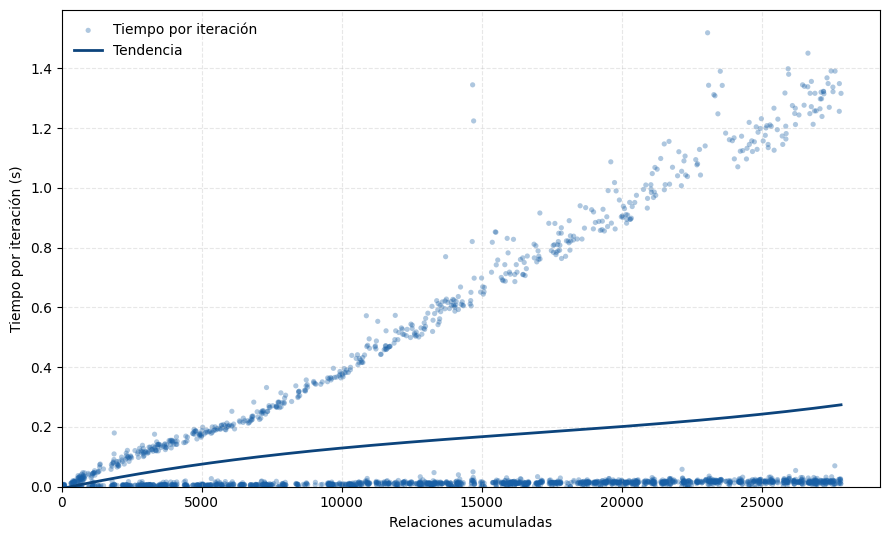

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el dataframe de resultados por iteración
df = pd.read_pickle("../Output/experiments/df_resultados_iteraciones_sinpca_dedup_20260630_051928.pkl")

# 2. Quedarse con las iteraciones que tienen tiempo medido y ordenarlas
val = df.dropna(subset=["tiempo_iteracion_segundos"]).sort_values("total_relaciones")

x = val["total_relaciones"].to_numpy()
y = val["tiempo_iteracion_segundos"].to_numpy()

# 3. Curva de ajuste: polinomio de grado 3 sobre la nube de puntos
coef = np.polyfit(x, y, deg=3)
x_linea = np.linspace(x.min(), x.max(), 200)
y_linea = np.polyval(coef, x_linea)

# 4. Dibujar
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(x, y, s=14, color="#185FA5", alpha=0.35, edgecolors="none",
           label="Tiempo por iteración")
ax.plot(x_linea, y_linea, color="#0C447C", linewidth=2,
        label="Tendencia")

ax.set_xlabel("Relaciones acumuladas")
ax.set_ylabel("Tiempo por iteración (s)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(loc="upper left", frameon=False)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("exp6_coste_computacional.png", dpi=300, bbox_inches="tight")
plt.savefig("exp6_coste_computacional.svg", bbox_inches="tight")
plt.show()

Pasada de referencia: 2374 iteraciones, 27838 relaciones, 78 clusters finales, ruido final 22.55%

umbral | iteración | % corpus | % clusters finales
  0.04  |     269 |   11.3% |   30.8%
  0.02  |     847 |   37.5% |   65.4%

Figura guardada en: calibracion_referencia_pca20.png


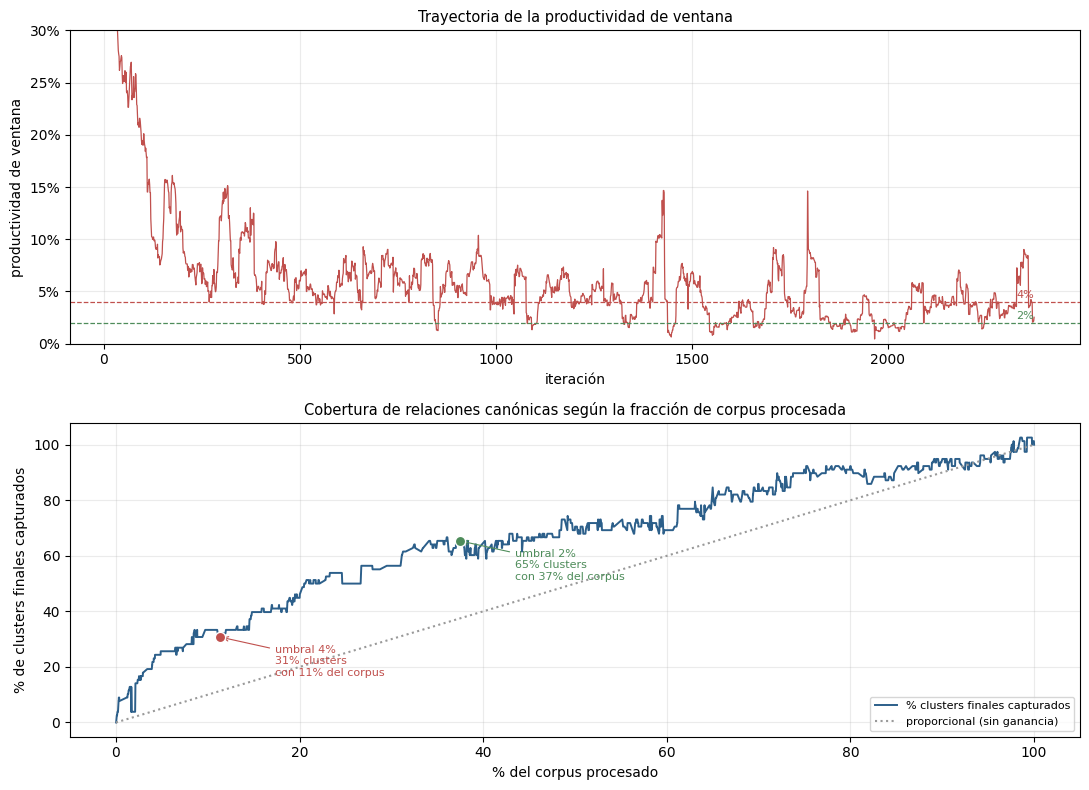

In [9]:
"""
Gráficas de calibración a partir del dataframe de resultados por iteración.

Gráficas:
  1) Trayectoria de la productividad de ventana a lo largo de las iteraciones,
     con las líneas de los umbrales candidatos.
  2) Curva de compromiso completitud-vs-cómputo: % de clusters finales
     capturados frente al % del corpus procesado, con los puntos de parada
     que provocaría cada umbral.

Uso en notebook (df ya en memoria o ruta al pickle):
    fig = generar_graficas_calibracion(df_resultados, umbrales=[0.04, 0.02])
    fig = generar_graficas_calibracion("df_resultados_iteraciones_....pkl")

"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


def fmt_pct(u):
    """Formatea un umbral decimal como porcentaje: 0.04 -> '4%', 0.005 -> '0.5%'."""
    v = u * 100
    return f"{v:.0f}%" if v == int(v) else f"{v:.1f}%"
 
# ---------------------------------------------------------------------------
# Configuración
# ---------------------------------------------------------------------------
UMBRALES = [0.04, 0.02]            # umbrales de productividad a marcar
OUTPUT_PATH = "calibracion_referencia_pca20.png"   # imagen de salida (None = no guardar)
COLORES_UMBRAL = ["#c0504d", "#4e8c5a", "#8a6d3b", "#7a5c9e"]   # se reciclan
 
# Nombres de columna esperados en el dataframe de resultados
COL_ITER = "iteration"
COL_RELACIONES = "total_relaciones"
COL_CLUSTERS = "total_clusters"
COL_RUIDO_PCT = "noise_percentage"
COL_PRODUCTIVIDAD = "ratio_productividad_conocimiento_ventana"
 
 
# ---------------------------------------------------------------------------
# Cálculo del punto de parada que provocaría un umbral
# ---------------------------------------------------------------------------
def primer_cruce(df, umbral):
    """Primera iteración en que la productividad de ventana cae a <= umbral.
 
    Devuelve un dict con iteración, % de corpus procesado y % de clusters
    finales capturados en ese punto, o None si nunca cruza.
    """
    dv = df.dropna(subset=[COL_PRODUCTIVIDAD])
    cr = dv[dv[COL_PRODUCTIVIDAD] <= umbral]
    if len(cr) == 0:
        return None
    r = cr.iloc[0]
    final = df.iloc[-1]
    return {
        "umbral": umbral,
        "iteration": int(r[COL_ITER]),
        "pct_corpus": 100 * r[COL_RELACIONES] / final[COL_RELACIONES],
        "pct_clusters": 100 * r[COL_CLUSTERS] / final[COL_CLUSTERS],
    }
 
 
# ---------------------------------------------------------------------------
# Generación de las gráficas
# ---------------------------------------------------------------------------
def generar_graficas_calibracion(df, umbrales=UMBRALES,
                                 output_path=OUTPUT_PATH, mostrar_tabla=True):
    """`df` puede ser un DataFrame ya cargado o la ruta a un pickle."""
    if isinstance(df, str):
        df = pd.read_pickle(df)
    df = df.sort_values(COL_ITER).reset_index(drop=True)
 
    final = df.iloc[-1]
    Cf, Nf = final[COL_CLUSTERS], final[COL_RELACIONES]
    dv = df.dropna(subset=[COL_PRODUCTIVIDAD])
 
    cruces = [c for c in (primer_cruce(df, u) for u in umbrales) if c is not None]
 
    if mostrar_tabla:
        print(f"Pasada de referencia: {int(final[COL_ITER])} iteraciones, "
              f"{int(Nf)} relaciones, {int(Cf)} clusters finales, "
              f"ruido final {final[COL_RUIDO_PCT]}%\n")
        print("umbral | iteración | % corpus | % clusters finales")
        for c in cruces:
            print(f"  {c['umbral']:<5} |   {c['iteration']:>5} | "
                  f"{c['pct_corpus']:6.1f}% | {c['pct_clusters']:6.1f}%")
 
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8))
 
    # --- Panel 1: productividad de ventana a lo largo de las iteraciones ---
    ax1.plot(dv[COL_ITER], dv[COL_PRODUCTIVIDAD] * 100, color="#c0504d", lw=0.9)
    for u, col in zip(umbrales, COLORES_UMBRAL):
        ax1.axhline(u * 100, ls="--", lw=0.9, color=col)
        ax1.text(dv[COL_ITER].max(), u * 100 + 0.4, fmt_pct(u),
                 color=col, fontsize=8, ha="right")
    ax1.set_ylabel("productividad de ventana")
    ax1.set_xlabel("iteración")
    ax1.set_ylim(0, max(30, dv[COL_PRODUCTIVIDAD].quantile(0.98) * 100))
    ax1.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    ax1.set_title("Trayectoria de la productividad de ventana", fontsize=10.5)
    ax1.grid(alpha=0.25)
 
    # --- Panel 2: completitud (% clusters finales) vs % corpus procesado ---
    pct_data = df[COL_RELACIONES] / Nf * 100
    pct_cl = df[COL_CLUSTERS] / Cf * 100
    ax2.plot(pct_data, pct_cl, color="#2c5f8a", lw=1.4,
             label="% clusters finales capturados")
    ax2.plot([0, 100], [0, 100], ls=":", color="#999",
             label="proporcional (sin ganancia)")
    for c, col in zip(cruces, COLORES_UMBRAL):
        x, y = c["pct_corpus"], c["pct_clusters"]
        ax2.scatter([x], [y], color=col, s=55, zorder=5, edgecolor="white")
        ax2.annotate(f"umbral {fmt_pct(c['umbral'])}\n{y:.0f}% clusters\n"
                     f"con {x:.0f}% del corpus",
                     xy=(x, y), xytext=(x + 6, y - 14), fontsize=8, color=col,
                     arrowprops=dict(arrowstyle="->", color=col, lw=0.8))
    ax2.set_xlabel("% del corpus procesado")
    ax2.set_ylabel("% de clusters finales capturados")
    ax2.set_title("Cobertura de relaciones canónicas según la fracción de corpus procesada", fontsize=10.5)
    ax2.legend(fontsize=8, loc="lower right")
    ax2.grid(alpha=0.25)
 
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=130, bbox_inches="tight")
        print(f"\nFigura guardada en: {output_path}")
    return fig


fig = generar_graficas_calibracion(df_resultados_iteraciones)
plt.show()